In [1]:
# ==========================================
# CART vs Random Forest – Bank Marketing Example
# Universidad de San Andrés – Data Science
# Guz Vinueza
# ==========================================

# --- 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns




In [14]:
# --- 2. Load dataset
# For Google Colab, you can upload it or download directly:
df = pd.read_csv("bank-full.csv", sep=";")
print("✅ Dataset loaded successfully — Shape:", df.shape)
df.head()



✅ Dataset loaded successfully — Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [15]:
# --- 3. Encode categorical variables
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])


In [16]:
# --- 4. Split train/test
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 36168, Test size: 9043


In [17]:
# --- 5. Train CART (Decision Tree)
cart = DecisionTreeClassifier(max_depth=5, random_state=42)
cart.fit(X_train, y_train)
y_pred_cart = cart.predict(X_test)

print("\n🌳 CART (Decision Tree) Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_cart), 3))
print(classification_report(y_test, y_pred_cart))



🌳 CART (Decision Tree) Results:
Accuracy: 0.897
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7985
           1       0.59      0.40      0.47      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.68      0.71      9043
weighted avg       0.88      0.90      0.89      9043



In [19]:
# --- 6. Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n🌲 Random Forest Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print(classification_report(y_test, y_pred_rf))


🌲 Random Forest Results:
Accuracy: 0.906
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.66      0.42      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043



In [20]:
# --- 7. Compare Performance
results = pd.DataFrame({
    'Model': ['CART', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_cart), accuracy_score(y_test, y_pred_rf)]
})
print("\n🔍 Model Comparison:")
display(results)




🔍 Model Comparison:


,Model,Accuracy
0,CART,0.897047
1,Random Forest,0.906336


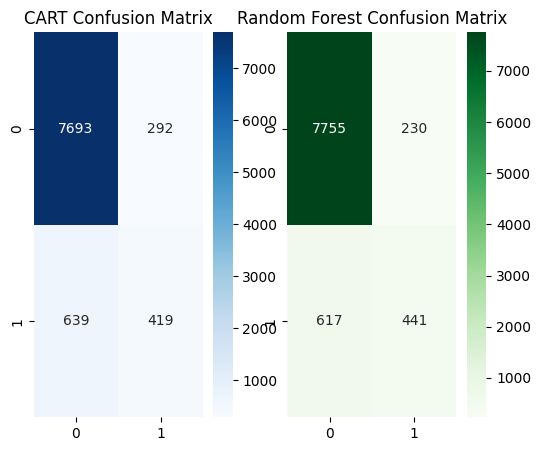

In [22]:
# --- 8. Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_cart), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("CART Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("Random Forest Confusion Matrix")
plt.show()



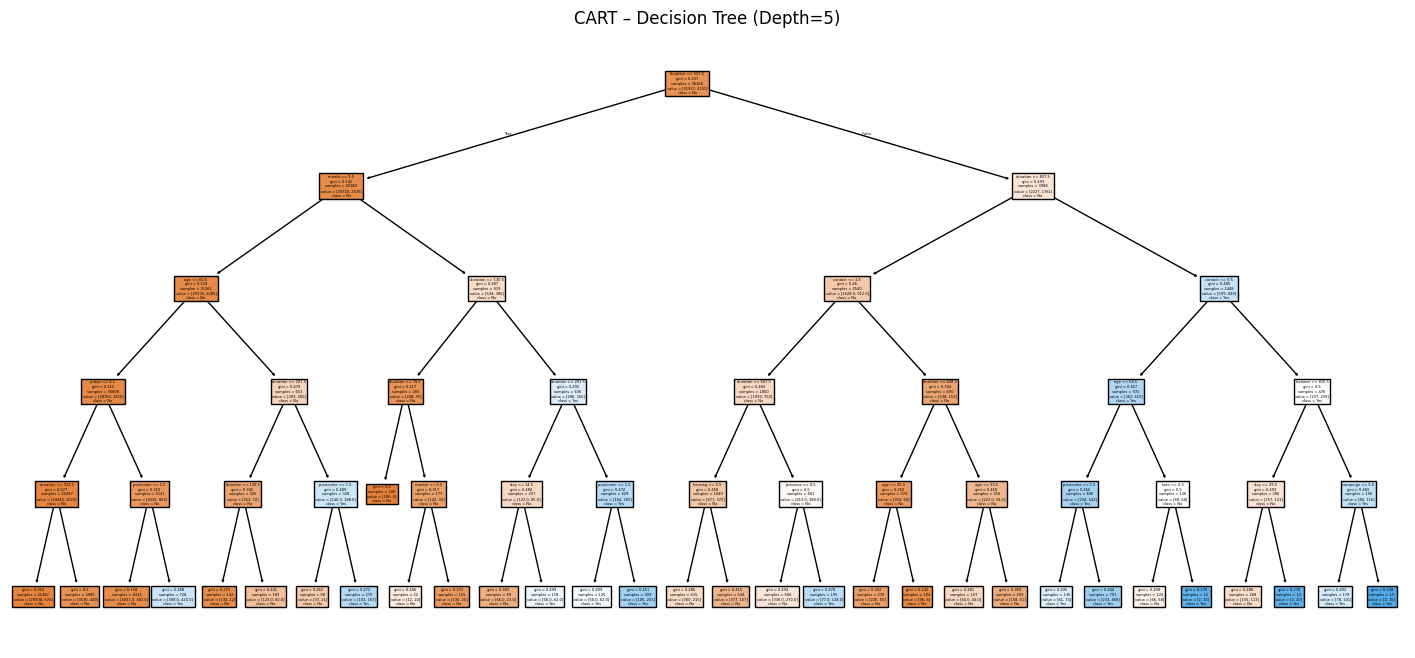

In [23]:
# --- 9. Visualize CART Tree (small depth for clarity)
plt.figure(figsize=(18,8))
plot_tree(cart, filled=True, feature_names=X.columns, class_names=['No', 'Yes'])
plt.title("CART – Decision Tree (Depth=5)")
plt.show()

#

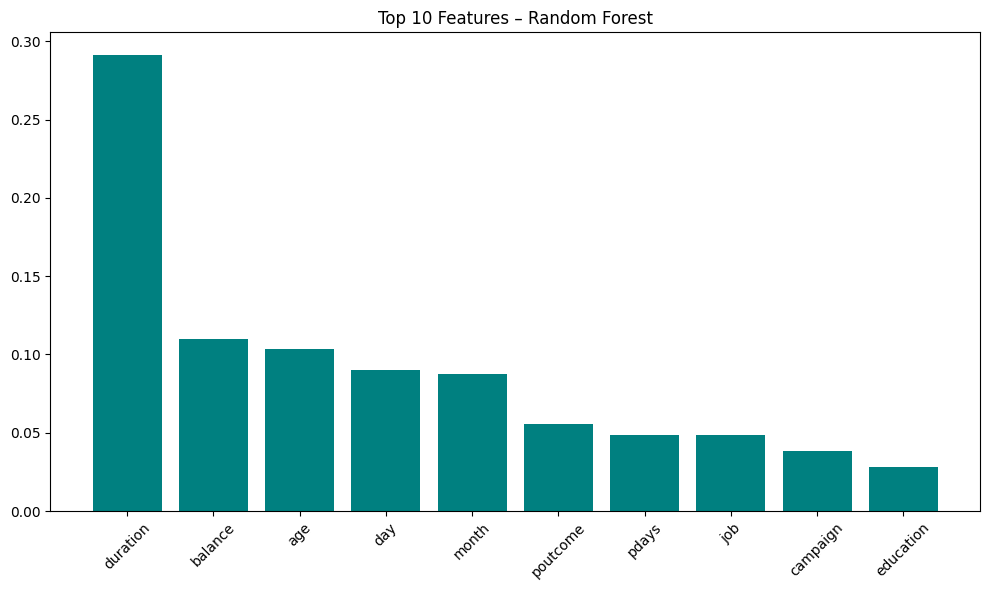

In [25]:
#--- 10. Feature Importance (Random Forest)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(10), importances[indices][:10], align='center', color='teal')
plt.xticks(range(10), X.columns[indices][:10], rotation=45)
plt.title("Top 10 Features – Random Forest")
plt.tight_layout()
plt.show()

